In [6]:
import pandas as pd
import numpy as np
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# 1. Load the data
# Adjust 'Date' to whatever your date column is named, or adjust the index logic.
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True) # m^3/s
df_sim = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)  # mm/day
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) # Stations as index

# Find the common stations across all three datasets
common_stations = list(set(df_obs.columns) & set(df_sim.columns) & set(df_attr.index))
print(f"Found {len(common_stations)} common stations.")

# Filter datasets to keep only common stations
df_obs = df_obs[common_stations]
df_sim = df_sim[common_stations]
df_attr = df_attr.loc[common_stations]

# 2. Convert ground truth units from m^3/s to mm/day
# Assumption: Area in attributes is in km^2. 
# 1 m^3/s = (1 * 86400 s/day) / (Area * 1e6 m^2) * 1000 mm/m = 86.4 / Area (km^2)
for station in common_stations:
    area_km2 = df_attr.loc[station, 'basin_area_km2']
    df_obs[station] = df_obs[station] * (86.4 / area_km2)

# 3. Align dates (1980-2022 vs 2013-2022)
# The inner join on indices will automatically restrict both dataframes to 2013-2022
df_obs, df_sim = df_obs.align(df_sim, join='inner')

# 4. Define NSE function
def calculate_nse(obs, sim):
    """Calculates the Nash-Sutcliffe Efficiency."""
    # Drop NaNs to ensure calculation works properly
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs_valid = obs[valid_mask]
    sim_valid = sim[valid_mask]
    
    if len(obs_valid) == 0:
        return np.nan
        
    numerator = np.sum((obs_valid - sim_valid) ** 2)
    denominator = np.sum((obs_valid - np.mean(obs_valid)) ** 2)
    
    if denominator == 0: # Handle edge case of constant observed flow
        return np.nan
        
    return 1 - (numerator / denominator)

# 5. Calculate NSE for each station
nse_results = {}
for station in common_stations:
    obs_vals = df_obs[station].values
    sim_vals = df_sim[station].values
    nse_results[station] = calculate_nse(obs_vals, sim_vals)

nse_series = pd.Series(nse_results).dropna()

# 6. Report the statistics
print("\n--- NSE Summary Statistics ---")
print(f"Mean:   {nse_series.mean():.3f}")
print(f"Median: {nse_series.median():.3f}")
print(f"Max:    {nse_series.max():.3f}")
print(f"Min:    {nse_series.min():.3f}")
print("\n--- Quartiles ---")
print(f"25th Percentile (Q1): {nse_series.quantile(0.25):.3f}")
print(f"50th Percentile (Q2): {nse_series.quantile(0.50):.3f}")
print(f"75th Percentile (Q3): {nse_series.quantile(0.75):.3f}")

# Optional: You can save the NSE values for each station to a new CSV
nse_series.to_csv(OUTPUT_DATA_DIR / 'station_nse_results.csv', header=['NSE'])

Found 269 common stations.

--- NSE Summary Statistics ---
Mean:   0.608
Median: 0.728
Max:    0.964
Min:    -1.521

--- Quartiles ---
25th Percentile (Q1): 0.451
50th Percentile (Q2): 0.728
75th Percentile (Q3): 0.863


Perform clustering on the streamflow data

Starting imputation...
Computing hydrographs and clustering...
Plotting dendrogram...


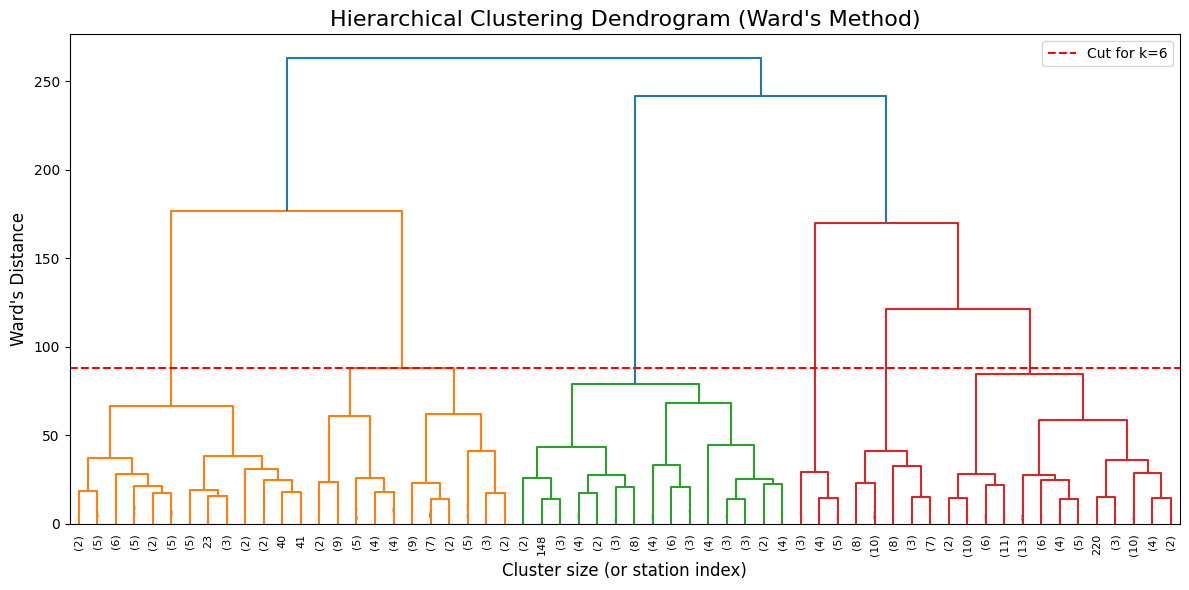

Plotting map...


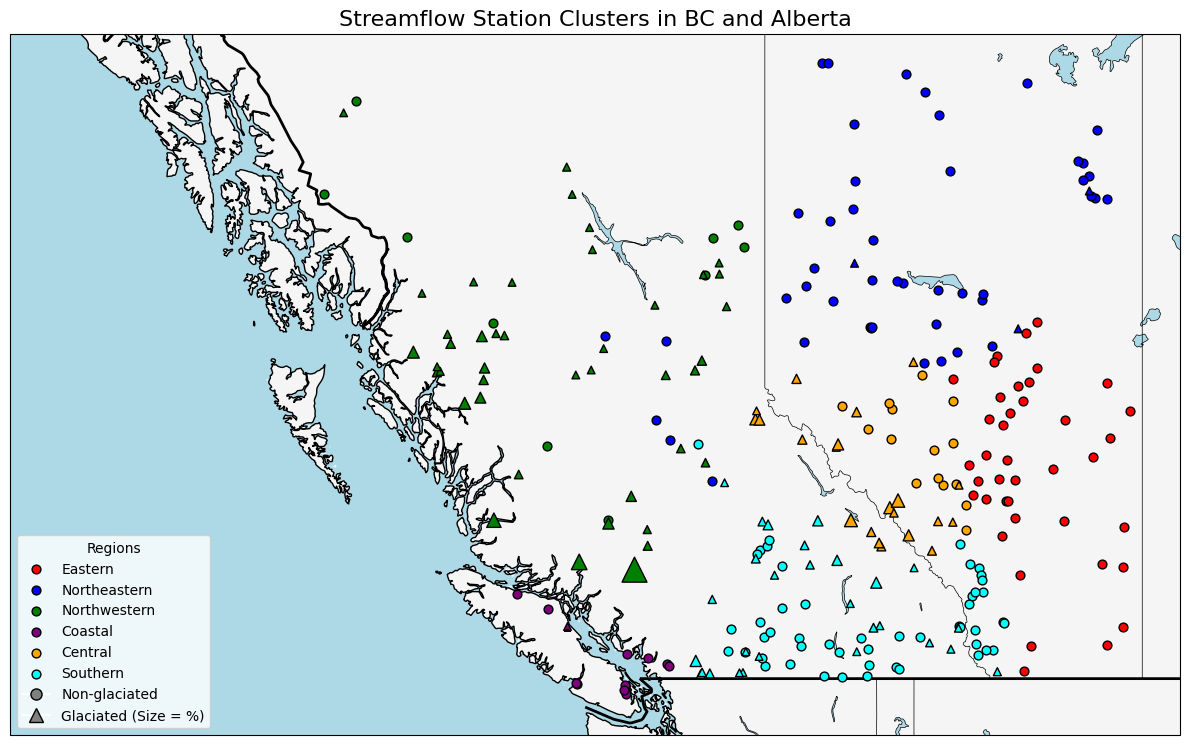

Plotting hydrographs...


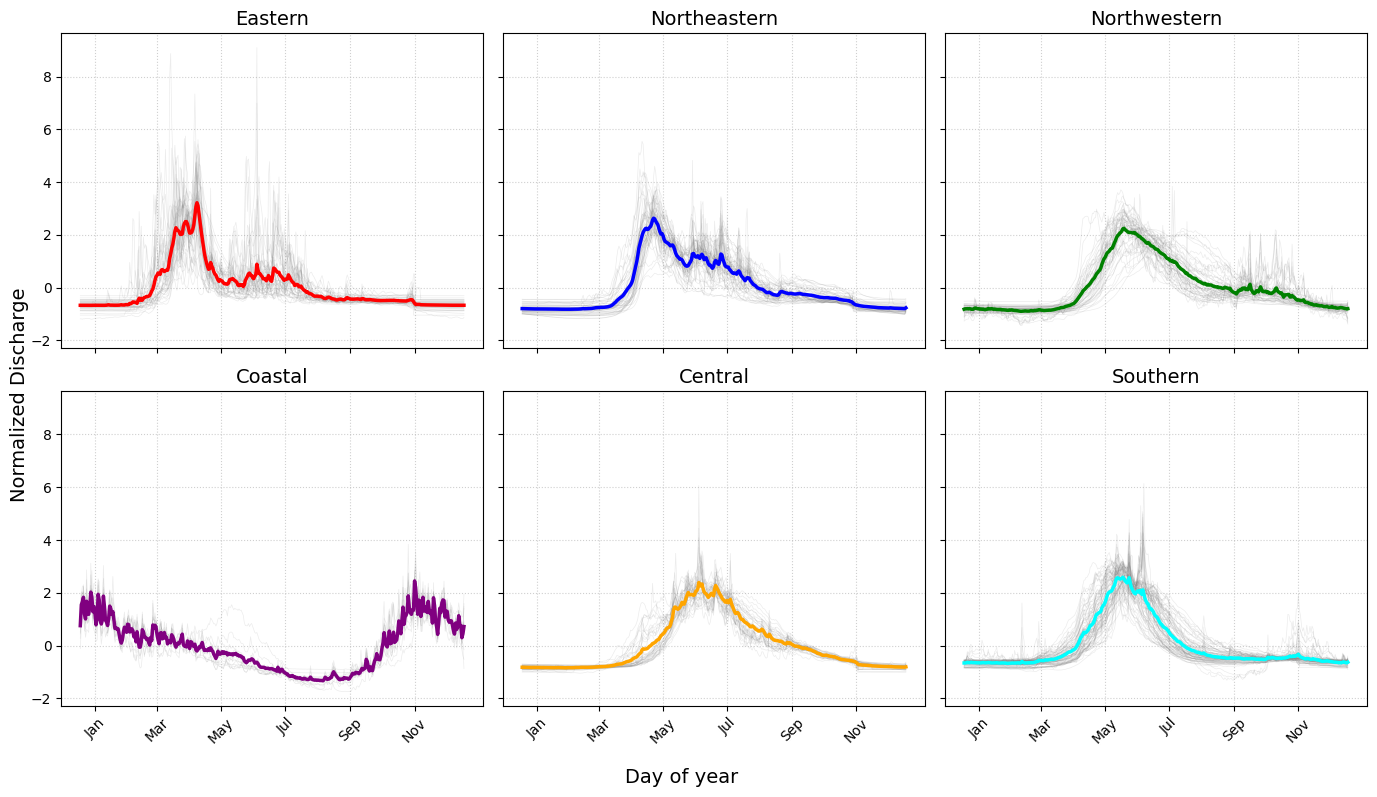

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0) 
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

df_obs.index = pd.to_datetime(df_obs.index)

# =========================================================
# 2. Imputation
# =========================================================
print("Starting imputation...")
df_obs = df_obs.interpolate(method='linear', limit=7)

doy_mean = df_obs.groupby(df_obs.index.dayofyear).transform('mean')
df_obs = df_obs.fillna(doy_mean)

annual_min = df_obs.groupby(df_obs.index.year).transform('min')
df_obs = df_obs.fillna(annual_min)
df_obs = df_obs.fillna(df_obs.min())

# =========================================================
# 3. Average Hydrograph & Normalization (Rolling Avg Removed)
# =========================================================
print("Computing hydrographs and clustering...")
# Calculate the daily average across all years for each station
avg_hydrograph = df_obs.groupby(df_obs.index.dayofyear).mean()

# Normalize to mean=0, std=1
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

# =========================================================
# 4. Ward's Hierarchical Clustering
# =========================================================
X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_meta[['Latitude', 'Longitude']], how='inner')

hydro_features = X_merged.drop(columns=['Latitude', 'Longitude']).values

# Normalize Spatial Features
lat_norm = (X_merged['Latitude'] - X_merged['Latitude'].mean()) / X_merged['Latitude'].std()
lon_norm = (X_merged['Longitude'] - X_merged['Longitude'].mean()) / X_merged['Longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))

# Generate the linkage matrix using Ward's method
Z = linkage(X_cluster_input, method='ward')

# =========================================================
# 5. Plot Dendrogram
# =========================================================
print("Plotting dendrogram...")
fig_dendro = plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)", fontsize=16)
dendrogram(
    Z,
    truncate_mode='lastp',  # Show only the last p merged clusters if there are too many stations
    p=60,                   # Adjust this number to show more/less branches
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True
)
plt.xlabel("Cluster size (or station index)", fontsize=12)
plt.ylabel("Ward's Distance", fontsize=12)
# Draw a horizontal line to show where we cut the tree for k=6
cut_distance = Z[-(7-1), 2]  # approximate threshold for 6 clusters
plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Cut for k=6')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. Extract Clusters & Prep for Mapping
# =========================================================
# Extract exactly 6 clusters. fcluster returns 1-indexed labels, so subtract 1.
cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_clusters = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_clusters.join(df_meta[['Latitude', 'Longitude']], how='inner')
df_plot = df_plot.join(df_attr[['glacier_pct']], how='left')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {
    0: "Eastern",
    1: "Northeastern",
    2: "Northwestern",
    3: "Coastal",
    4: "Central",
    5: "Southern"
}

colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']

# =========================================================
# 7. Plotting Map
# =========================================================
print("Plotting map...")
fig_map = plt.figure(figsize=(12, 10))
ax_map = plt.axes(projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale=res, facecolor='none'
)
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

for cluster_id in range(6):
    cluster_data = df_plot[df_plot['Cluster'] == cluster_id]
    non_glac = cluster_data[cluster_data['glacier_pct'] == 0]
    glac = cluster_data[cluster_data['glacier_pct'] > 0]
    
    label_name = cluster_names[cluster_id]
    
    if not non_glac.empty:
        ax_map.scatter(
            non_glac['Longitude'], non_glac['Latitude'], 
            transform=ccrs.PlateCarree(),
            color=colors[cluster_id], 
            s=40, marker='o', edgecolors='k', zorder=5,
            label=label_name
        )
        
    if not glac.empty:
        triangle_sizes = (glac['glacier_pct'] * 5) + 30 
        ax_map.scatter(
            glac['Longitude'], glac['Latitude'], 
            transform=ccrs.PlateCarree(),
            color=colors[cluster_id], 
            s=triangle_sizes, marker='^', edgecolors='k', zorder=5
        )

handles, labels = ax_map.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
circle_marker = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated')
triangle_marker = mlines.Line2D([], [], color='white', marker='^', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated (Size = %)')
legend_handles = list(unique_labels.values()) + [circle_marker, triangle_marker]

plt.title('Streamflow Station Clusters in BC and Alberta', fontsize=16)
plt.legend(handles=legend_handles, loc='lower left', title="Regions")
plt.tight_layout()
plt.show()

# =========================================================
# 8. Hydrograph Grids 
# =========================================================
print("Plotting hydrographs...")
fig_hydro, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    ax = axes[cluster_id]
    station_names = df_clusters[df_clusters['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    
    ax.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.15, linewidth=0.5)
    
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax.plot(cluster_mean.index, cluster_mean.values, color=colors[cluster_id], linewidth=2.5)
    
    ax.set_title(cluster_names[cluster_id], fontsize=14)
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=45)
    ax.grid(True, linestyle=':', alpha=0.6)

fig_hydro.supxlabel('Day of year', fontsize=14)
fig_hydro.supylabel('Normalized Discharge', fontsize=14)
plt.tight_layout()
plt.show()

Plotting NSE map...


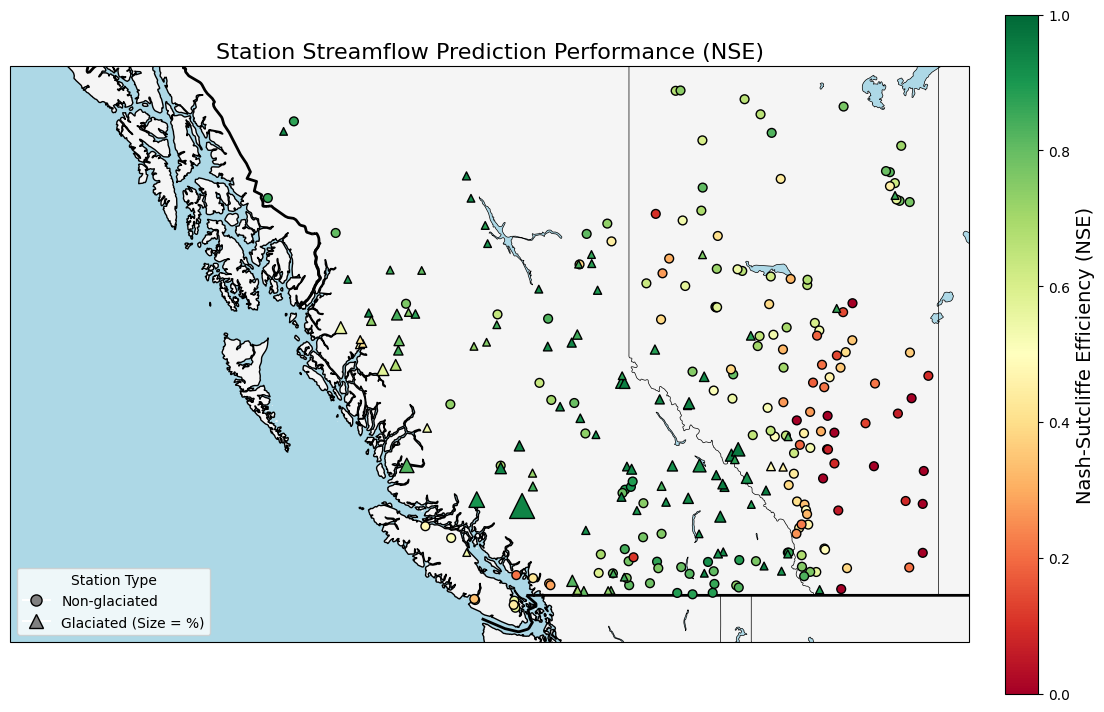

Plotting NSE boxplots...


C:\Users\tbwil\AppData\Local\Temp\ipykernel_7564\1461405755.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


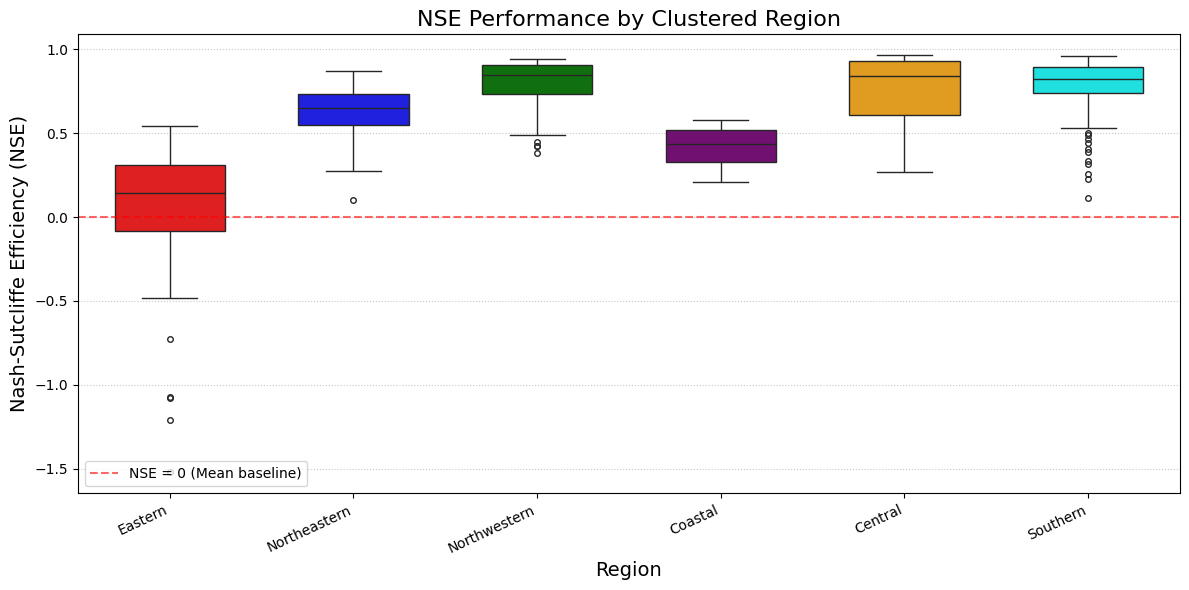

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import seaborn as sns
from src.config import OUTPUT_DATA_DIR

# =========================================================
# 1. Load NSE Data and Merge
# =========================================================
# Load the NSE results computed previously
df_nse = pd.read_csv(OUTPUT_DATA_DIR / 'station_nse_results.csv', index_col=0)

# Merge the NSE data with our existing plotting dataframe
# df_plot contains Latitude, Longitude, Cluster, and glacier_pct
df_merged = df_plot.join(df_nse, how='inner')

# Add the descriptive cluster names for the box plot
df_merged['Cluster_Name'] = df_merged['Cluster'].map(cluster_names)

# Define color scale limits for the map (capping min NSE for better color contrast)
# vmin = max(-1.0, df_merged['NSE'].quantile(0.05)) # Cap visual min at -1.0 or 5th percentile
vmin = 0
vmax = 1.0 # Perfect NSE

# =========================================================
# 2. NSE Spatial Map
# =========================================================
print("Plotting NSE map...")
fig_map = plt.figure(figsize=(12, 10))
ax_map = plt.axes(projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

# --- Map Features ---
res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale=res, facecolor='none'
)
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

# --- Plotting Stations ---
non_glac = df_merged[df_merged['glacier_pct'] == 0]
glac = df_merged[df_merged['glacier_pct'] > 0]

# Using 'viridis' colormap where yellow is high NSE (good) and dark purple is low (bad)
# cmap = 'viridis'
cmap = 'RdYlGn'

if not non_glac.empty:
    sc_circles = ax_map.scatter(
        non_glac['Longitude'], non_glac['Latitude'], 
        transform=ccrs.PlateCarree(),
        c=non_glac['NSE'], cmap=cmap, vmin=vmin, vmax=vmax,
        s=40, marker='o', edgecolors='k', zorder=5
    )
    
if not glac.empty:
    triangle_sizes = (glac['glacier_pct'] * 5) + 30 
    sc_triangles = ax_map.scatter(
        glac['Longitude'], glac['Latitude'], 
        transform=ccrs.PlateCarree(),
        c=glac['NSE'], cmap=cmap, vmin=vmin, vmax=vmax,
        s=triangle_sizes, marker='^', edgecolors='k', zorder=5
    )

# --- Colorbar and Legend ---
# We use one of the scatter objects (sc_circles or sc_triangles) to generate the colorbar
mappable = sc_circles if not non_glac.empty else sc_triangles
cbar = plt.colorbar(mappable, ax=ax_map, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label('Nash-Sutcliffe Efficiency (NSE)', fontsize=14)

# Keep the shape legend
circle_marker = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated')
triangle_marker = mlines.Line2D([], [], color='white', marker='^', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated (Size = %)')
plt.legend(handles=[circle_marker, triangle_marker], loc='lower left', title="Station Type")

plt.title('Station Streamflow Prediction Performance (NSE)', fontsize=16)
plt.tight_layout()
plt.show()

# =========================================================
# 3. NSE Box Plot by Cluster
# =========================================================
print("Plotting NSE boxplots...")
fig_box = plt.figure(figsize=(12, 6))

# Sort the dataframe so the clusters appear in order 0-5
df_merged_sorted = df_merged.sort_values('Cluster')

# Use seaborn to create a clean boxplot, matching the cluster colors from earlier
sns.boxplot(
    data=df_merged_sorted, 
    x='Cluster_Name', 
    y='NSE', 
    palette=colors,
    width=0.6,
    fliersize=4 # size of outlier points
)

# Add a dashed red reference line for an NSE of 0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.6, label='NSE = 0 (Mean baseline)')

plt.title('NSE Performance by Clustered Region', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=14)
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Analyzing 95 glaciated stations...
Overall Average Glacier Yield Ratio (August)
 Mean: 2.210
 Median: 0.24122831420041396
Correlation between Mass Balance Change and Streamflow Difference: 0.035 (p-value: 2.772e-01)


c:\Users\tbwil\Documents\School\MSc Geophysics\Thesis Project\.venv\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


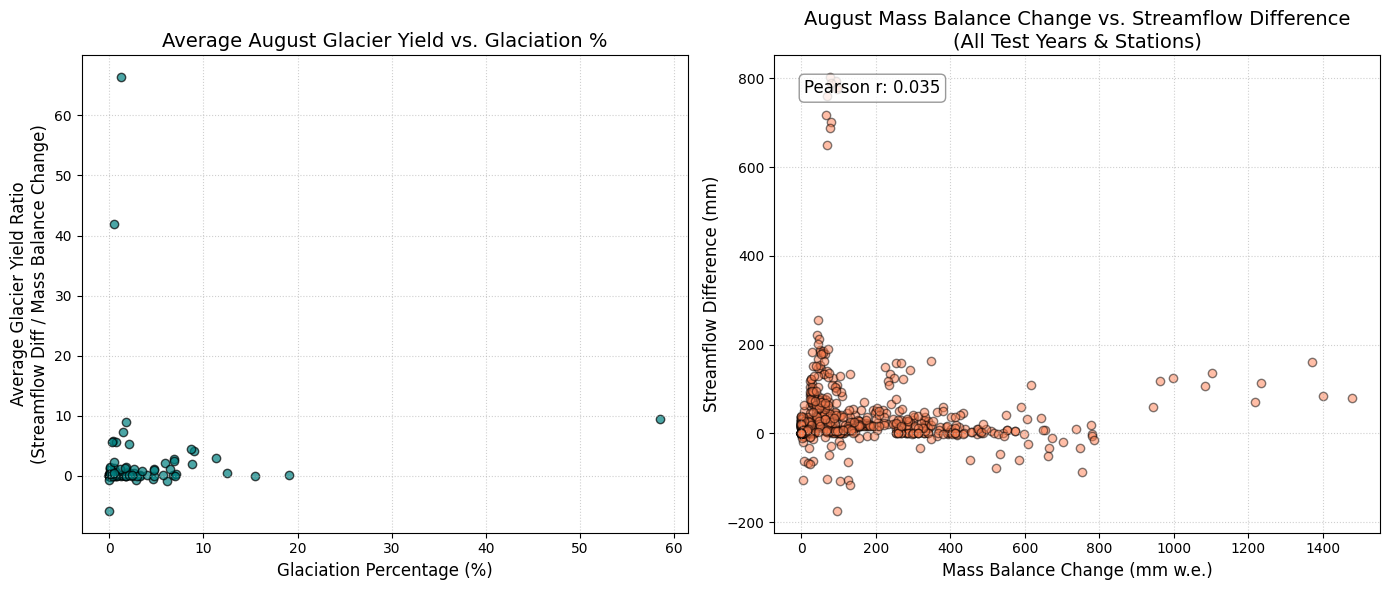

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
# Load predictions
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

# Load mass balance and attributes
# Assumes index is Date (1979-2022, monthly)
df_mb = - pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# =========================================================
# 2. Filter and Isolate August Data for Glaciated Stations
# =========================================================
# Identify glaciated stations common to all datasets
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
glaciated_stations = glaciated_stations.intersection(df_pred.columns).intersection(df_mb.columns)

print(f"Analyzing {len(glaciated_stations)} glaciated stations...")

# Filter predictions for glaciated stations
df_pred = df_pred[glaciated_stations]
df_pred_no_glac = df_pred_no_glac[glaciated_stations]

# Calculate daily difference (Prediction with Glacier - Prediction without Glacier)
df_diff = df_pred - df_pred_no_glac

# Filter for August (Month == 8)
df_diff_aug = df_diff[df_diff.index.month == 8]
df_mb_aug = df_mb[df_mb.index.month == 8]

# Sum the streamflow difference for the month of August for each year
# (Going from daily mm/day to monthly sum in mm)
df_diff_aug_yearly = df_diff_aug.groupby(df_diff_aug.index.year).sum()

# Extract the August mass balance for each year
# Since it's already monthly resolution, grouping by year and taking the first/sum will yield the August value
df_mb_aug_yearly = df_mb_aug.groupby(df_mb_aug.index.year).sum()[glaciated_stations]

# Align the years between the test dataset (e.g., 2013-2022) and mass balance dataset
common_years = df_diff_aug_yearly.index.intersection(df_mb_aug_yearly.index)
df_diff_aug_yearly = df_diff_aug_yearly.loc[common_years]
df_mb_aug_yearly = df_mb_aug_yearly.loc[common_years]

# =========================================================
# 3. Calculate Glacier Yield Ratio
# =========================================================
# Optional: If mass balance loss is negative and you want a positive yield ratio, 
# uncomment the absolute function below.
# df_mb_aug_yearly = df_mb_aug_yearly.abs()

# Ratio: streamflow difference / change in mass balance
ratio_yearly = df_diff_aug_yearly / df_mb_aug_yearly

# Average the ratio for each station across all available test years
avg_ratio_per_station = ratio_yearly.mean()

# Replace any inf/-inf with NaN to avoid calculation errors
avg_ratio_per_station.replace([np.inf, -np.inf], np.nan, inplace=True)

# Report the overall average across all stations
print(f"Overall Average Glacier Yield Ratio (August)\n Mean: {avg_ratio_per_station.mean():.3f}\n Median: {avg_ratio_per_station.median()}")

# =========================================================
# 4. Prepare Data for Scatter Plots
# =========================================================
# Plot 1 Data: Glacier Yield vs Glaciation %
glac_pct = df_attr.loc[glaciated_stations, 'glacier_pct']

# Plot 2 Data: Flatten the yearly dataframes to get every station-year combination
mb_flat = df_mb_aug_yearly.values.flatten()
diff_flat = df_diff_aug_yearly.values.flatten()

# Filter out NaNs for the correlation calculation
valid_mask = ~(np.isnan(mb_flat) | np.isnan(diff_flat))
mb_flat_clean = mb_flat[valid_mask]
diff_flat_clean = diff_flat[valid_mask]

# Calculate Pearson Correlation
corr, p_value = stats.pearsonr(mb_flat_clean, diff_flat_clean)
print(f"Correlation between Mass Balance Change and Streamflow Difference: {corr:.3f} (p-value: {p_value:.3e})")

# =========================================================
# 5. Plotting
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Plot: Glacier Yield vs Glaciation Percentage ---
axes[0].scatter(glac_pct, avg_ratio_per_station, color='teal', alpha=0.7, edgecolor='k')
axes[0].set_title('Average August Glacier Yield vs. Glaciation %', fontsize=14)
axes[0].set_xlabel('Glaciation Percentage (%)', fontsize=12)
axes[0].set_ylabel('Average Glacier Yield Ratio\n(Streamflow Diff / Mass Balance Change)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- Right Plot: Mass Balance Change vs Streamflow Difference ---
axes[1].scatter(mb_flat_clean, diff_flat_clean, color='coral', alpha=0.5, edgecolor='k')
axes[1].set_title('August Mass Balance Change vs. Streamflow Difference\n(All Test Years & Stations)', fontsize=14)
axes[1].set_xlabel('Mass Balance Change (mm w.e.)', fontsize=12)
axes[1].set_ylabel('Streamflow Difference (mm)', fontsize=12)

# Add correlation text to the plot
textstr = f'Pearson r: {corr:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes, fontsize=12,
             verticalalignment='top', bbox=props)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()